# Analyse worm species classification outputs

This notebook is tailored to your current output-folder structure, for example:

```text
outputs/
└── vit_b_16__rel_path_seg__species_label__b9d9c7a0/
    ├── best_model.pt
    ├── config.json
    ├── history.csv
    ├── split_summary.json
    ├── classification_report.csv
    ├── confusion_matrix.csv
    ├── label_to_index.json
    └── test_metrics.json
```

It will:
- read all run folders inside `outputs/`;
- load `config.json`, `history.csv`, `test_metrics.json`, `classification_report.csv`, and `confusion_matrix.csv`;
- rank all runs;
- find the best run per model and per sweep condition;
- plot training curves;
- plot confusion matrices for the top runs directly from `confusion_matrix.csv`;
- export cleaned summary tables to `outputs/_analysis/`.


In [17]:
# -----------------------------
# 0. USER SETTINGS
# -----------------------------
from pathlib import Path

PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "config.yaml").is_file()), Path.cwd())
OUTPUT_ROOT = PROJECT_ROOT / "outputs"   # change if needed
TOP_K = 10                      # number of top runs to show in tables
TOP_K_CONFUSION = 5             # number of top confusion matrices to plot
PRIMARY_METRIC = "test_macro_f1"

OUTPUT_ROOT.resolve()


PosixPath('/home/devd/worm-species/outputs')

In [18]:
# -----------------------------
# 1. IMPORTS
# -----------------------------
import json
import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)


## 1. Helper functions

In [3]:
# -----------------------------
# 2. HELPERS
# -----------------------------
def read_json(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def read_json_if_exists(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        return read_json(path)
    except Exception as e:
        print(f"Could not read JSON {path}: {e}")
        return None


def read_csv_if_exists(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Could not read CSV {path}: {e}")
        return None


def flatten_dict(d: dict, prefix: str = "") -> dict:
    """Flatten nested dictionaries using dot-separated keys."""
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(flatten_dict(v, key))
        else:
            out[key] = v
    return out


def get_nested(d: dict | None, keys: list[str], default=None):
    if d is None:
        return default
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


def infer_model_from_run_name(run_name: str) -> str | None:
    known_models = [
        "efficientnet_b0", "efficientnet_b1", "efficientnet_b2",
        "resnet18", "resnet34", "resnet50", "resnet101",
        "swin_t", "swin_s", "swin_b",
        "vit_b_16", "vit_b_32", "vit_l_16",
    ]
    rn = str(run_name).lower()
    for model in sorted(known_models, key=len, reverse=True):
        if model in rn:
            return model
    if "__" in rn:
        return rn.split("__")[0]
    return None


def normalise_metric_keys(metrics: dict) -> dict:
    """Convert metrics to a consistent test_* naming scheme."""
    out = {}
    for k, v in metrics.items():
        key = str(k)
        if key.startswith("test_"):
            out[key] = v
        else:
            out[f"test_{key}"] = v
    return out


def numeric_or_original(x):
    try:
        return pd.to_numeric(x)
    except Exception:
        return x


## 2. Build a run-level summary table

This section reads each run folder and extracts:
- model settings from `config.json`;
- best validation metrics from `history.csv`;
- final test metrics from `test_metrics.json`;
- availability of `classification_report.csv` and `confusion_matrix.csv`.


In [4]:
# -----------------------------
# 3. BUILD SUMMARY TABLE
# -----------------------------
if not OUTPUT_ROOT.exists():
    raise FileNotFoundError(f"Could not find OUTPUT_ROOT: {OUTPUT_ROOT.resolve()}")

run_dirs = sorted([p for p in OUTPUT_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])
print(f"Found {len(run_dirs)} run directories in {OUTPUT_ROOT.resolve()}")

rows = []

for run_dir in run_dirs:
    run_name = run_dir.name

    cfg = read_json_if_exists(run_dir / "config.json")
    metrics = read_json_if_exists(run_dir / "test_metrics.json")
    split_summary = read_json_if_exists(run_dir / "split_summary.json")

    row = {
        "run_name": run_name,
        "out_dir": str(run_dir),
        "has_best_model": (run_dir / "best_model.pt").exists(),
        "has_config": cfg is not None,
        "has_history": (run_dir / "history.csv").exists(),
        "has_test_metrics": metrics is not None,
        "has_classification_report": (run_dir / "classification_report.csv").exists(),
        "has_confusion_matrix": (run_dir / "confusion_matrix.csv").exists(),
    }

    # Config fields
    row["model_name"] = get_nested(cfg, ["model", "name"], default=infer_model_from_run_name(run_name))
    row["pretrained"] = get_nested(cfg, ["model", "pretrained"])
    row["freeze_backbone"] = get_nested(cfg, ["model", "freeze_backbone"])
    row["class_weight"] = get_nested(cfg, ["training", "class_weight"])
    row["image_size"] = get_nested(cfg, ["data", "image_size"])
    row["epochs_config"] = get_nested(cfg, ["training", "epochs"])
    row["batch_size"] = get_nested(cfg, ["training", "batch_size"])
    row["lr"] = get_nested(cfg, ["training", "lr"])
    row["weight_decay"] = get_nested(cfg, ["training", "weight_decay"])
    row["use_amp"] = get_nested(cfg, ["training", "use_amp"])

    # Optional early stopping fields, if present
    row["early_stopping_enabled"] = get_nested(cfg, ["early_stopping", "enabled"])
    row["early_stopping_patience"] = get_nested(cfg, ["early_stopping", "patience"])
    row["early_stopping_min_delta"] = get_nested(cfg, ["early_stopping", "min_delta"])

    # Split summary, if present
    if isinstance(split_summary, dict):
        flat_split = flatten_dict(split_summary)
        for k, v in flat_split.items():
            if isinstance(v, (str, int, float, bool)) or v is None:
                row[f"split_{k}"] = v

    # Test metrics
    if isinstance(metrics, dict):
        for k, v in normalise_metric_keys(metrics).items():
            if isinstance(v, (str, int, float, bool)) or v is None:
                row[k] = v

    # History-derived metrics
    hist = read_csv_if_exists(run_dir / "history.csv")
    if hist is not None and len(hist) > 0:
        row["n_epochs_ran"] = len(hist)

        if "val_macro_f1" in hist.columns:
            row["best_val_macro_f1"] = hist["val_macro_f1"].max()
            row["best_epoch_by_val_macro_f1"] = int(hist["val_macro_f1"].idxmax() + 1)
            row["last_val_macro_f1"] = hist["val_macro_f1"].iloc[-1]

        if "val_balanced_accuracy" in hist.columns:
            row["best_val_balanced_accuracy"] = hist["val_balanced_accuracy"].max()
            row["last_val_balanced_accuracy"] = hist["val_balanced_accuracy"].iloc[-1]

        if "val_accuracy" in hist.columns:
            row["best_val_accuracy"] = hist["val_accuracy"].max()
            row["last_val_accuracy"] = hist["val_accuracy"].iloc[-1]

        if "train_loss" in hist.columns:
            row["last_train_loss"] = hist["train_loss"].iloc[-1]

        if "val_loss" in hist.columns:
            row["last_val_loss"] = hist["val_loss"].iloc[-1]

    # Scientifically weak combination
    row["frozen_random_backbone"] = (
        row.get("pretrained") is False and row.get("freeze_backbone") is True
    )

    rows.append(row)

summary = pd.DataFrame(rows)

# Convert likely numeric columns
for c in summary.columns:
    if any(s in c.lower() for s in ["loss", "accuracy", "f1", "epoch", "size", "batch", "lr", "decay", "patience", "delta"]):
        summary[c] = pd.to_numeric(summary[c], errors="ignore")

print("Summary shape:", summary.shape)
display(summary.head())


Found 121 run directories in /home/devd/worm-species/outputs
Summary shape: (121, 43)


/tmp/ipykernel_1770729/1399764479.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  summary[c] = pd.to_numeric(summary[c], errors="ignore")


,run_name,out_dir,has_best_model,has_config,has_history,has_test_metrics,has_classification_report,has_confusion_matrix,model_name,pretrained,freeze_backbone,class_weight,image_size,epochs_config,batch_size,lr,weight_decay,use_amp,early_stopping_enabled,early_stopping_patience,early_stopping_min_delta,split_num_classes,split_train_rows,split_val_rows,split_test_rows,split_train_individuals,split_val_individuals,split_test_individuals,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,n_epochs_ran,best_val_macro_f1,best_epoch_by_val_macro_f1,last_val_macro_f1,best_val_balanced_accuracy,last_val_balanced_accuracy,best_val_accuracy,last_val_accuracy,last_train_loss,last_val_loss,frozen_random_backbone
0,efficientnet_b0__rel_path_seg__species_label__05b2333d,outputs/efficientnet_b0__rel_path_seg__species_label__05b2333d,True,True,True,True,True,True,efficientnet_b0,True,True,False,224,100,128,0.001,0.0001,True,True,15,0.001,8,3949,926,1228,710,164,219,1.368424,0.481270,0.466402,0.407491,52.0,0.471020,37.0,0.440448,0.573091,0.563422,0.515119,0.480562,1.110486,1.224667,False
1,efficientnet_b0__rel_path_seg__species_label__22643ffb,outputs/efficientnet_b0__rel_path_seg__species_label__22643ffb,True,True,True,True,True,True,efficientnet_b0,True,True,False,224,100,128,0.001,0.0001,True,True,15,0.001,6,3780,857,1195,679,157,209,1.112328,0.589121,0.582773,0.553492,64.0,0.597280,49.0,0.570017,0.634988,0.620702,0.607935,0.578763,0.977295,0.982255,False
2,efficientnet_b0__rel_path_seg__species_label__270824d1,outputs/efficientnet_b0__rel_path_seg__species_label__270824d1,True,True,True,True,True,True,efficientnet_b0,False,True,True,224,100,128,0.001,0.0001,True,True,15,0.001,8,3949,926,1228,710,164,219,2.018848,0.141694,0.154289,0.085466,35.0,0.125392,20.0,0.090653,0.241871,0.201614,0.211663,0.109071,1.993837,2.022454,True
3,efficientnet_b0__rel_path_seg__species_label__278007df,outputs/efficientnet_b0__rel_path_seg__species_label__278007df,True,True,True,True,True,True,efficientnet_b0,True,True,True,224,100,128,0.001,0.0001,True,True,15,0.001,8,3949,926,1228,710,164,219,1.368424,0.481270,0.466402,0.407491,52.0,0.471020,37.0,0.440448,0.573091,0.563422,0.515119,0.480562,1.110486,1.224667,False
4,efficientnet_b0__rel_path_seg__species_label__5c0a3931,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931,True,True,True,True,True,True,efficientnet_b0,False,False,False,224,100,128,0.001,0.0001,True,True,15,0.001,6,3780,857,1195,679,157,209,0.662080,0.879498,0.874986,0.872376,82.0,0.883488,72.0,0.866574,0.904996,0.876144,0.891482,0.879813,0.014049,0.554180,False


## 3. Rank all runs

For imbalanced species classification, `test_macro_f1` is usually more informative than raw accuracy because it weights each species equally.


In [5]:
# -----------------------------
# 4. RANK RUNS
# -----------------------------
metric_priority = [
    PRIMARY_METRIC,
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_accuracy",
    "best_val_macro_f1",
]

available_metrics = [m for m in metric_priority if m in summary.columns]
if not available_metrics:
    raise ValueError(
        "Could not find any ranking metric. Available columns are:\n"
        + "\n".join(summary.columns.astype(str))
    )

rank_metric = available_metrics[0]
print("Ranking by:", rank_metric)

ranked = summary.sort_values(rank_metric, ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))

cols_main = [
    "rank", "run_name", "model_name",
    "pretrained", "freeze_backbone", "class_weight", "image_size",
    "best_val_macro_f1", "test_macro_f1", "test_balanced_accuracy", "test_accuracy", "test_loss",
    "n_epochs_ran", "best_epoch_by_val_macro_f1",
    "frozen_random_backbone",
    "has_confusion_matrix",
    "out_dir",
]
cols_main = [c for c in cols_main if c in ranked.columns]

display(ranked[cols_main].head(TOP_K))


Ranking by: test_macro_f1


,rank,run_name,model_name,pretrained,freeze_backbone,class_weight,image_size,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,has_confusion_matrix,out_dir
0,1,efficientnet_b0__rel_path_seg__species_label__d613e883,efficientnet_b0,True,False,True,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
1,2,efficientnet_b0__rel_path_seg__species_label__80e7075a,efficientnet_b0,True,False,False,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
2,3,efficientnet_b0__rel_path_seg__species_label__5c0a3931,efficientnet_b0,False,False,False,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931
3,4,efficientnet_b0__rel_path_seg__species_label__7fd6ebbe,efficientnet_b0,False,False,True,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe
4,5,resnet50__rel_path_seg__species_label__3b4fed59,resnet50,True,False,True,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,True,outputs/resnet50__rel_path_seg__species_label__3b4fed59
5,6,resnet50__rel_path_seg__species_label__444ed097,resnet50,True,False,False,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,True,outputs/resnet50__rel_path_seg__species_label__444ed097
6,7,resnet18__rel_path_seg__species_label__fc235d3a,resnet18,True,False,True,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,True,outputs/resnet18__rel_path_seg__species_label__fc235d3a
7,8,resnet18__rel_path_seg__species_label__a6e23b1f,resnet18,True,False,False,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,True,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
8,9,resnet50__rel_path_seg__species_label__03f76fef,resnet50,False,False,True,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,True,outputs/resnet50__rel_path_seg__species_label__03f76fef
9,10,resnet50__rel_path_seg__species_label__cefdfc0c,resnet50,False,False,False,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,True,outputs/resnet50__rel_path_seg__species_label__cefdfc0c


## 4. Best run for each case

This section finds the best run within each experimental condition:
- best per model;
- best per pretrained setting;
- best per freeze-backbone setting;
- best per class-weight setting;
- best per full sweep case.


In [6]:
# -----------------------------
# 5. BEST BY GROUP
# -----------------------------
def best_by_group(df: pd.DataFrame, group_cols: list[str], metric: str) -> pd.DataFrame | None:
    group_cols = [c for c in group_cols if c in df.columns]
    if not group_cols or metric not in df.columns:
        return None

    valid = df.dropna(subset=[metric]).copy()
    if len(valid) == 0:
        return None

    idx = valid.groupby(group_cols, dropna=False)[metric].idxmax()
    out = valid.loc[idx].sort_values(metric, ascending=False).reset_index(drop=True)
    return out


groupings = {
    "Best per model": ["model_name"],
    "Best per pretrained setting": ["pretrained"],
    "Best per freeze-backbone setting": ["freeze_backbone"],
    "Best per class-weight setting": ["class_weight"],
    "Best per model × pretrained": ["model_name", "pretrained"],
    "Best per model × freeze_backbone": ["model_name", "freeze_backbone"],
    "Best per model × class_weight": ["model_name", "class_weight"],
    "Best per full case": ["model_name", "pretrained", "freeze_backbone", "class_weight", "image_size"],
}

best_tables = {}

for title, group_cols in groupings.items():
    tbl = best_by_group(summary, group_cols, rank_metric)
    if tbl is None or len(tbl) == 0:
        continue

    best_tables[title] = tbl

    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)

    show_cols = group_cols + [
        "run_name",
        "best_val_macro_f1",
        "test_macro_f1",
        "test_balanced_accuracy",
        "test_accuracy",
        "test_loss",
        "n_epochs_ran",
        "best_epoch_by_val_macro_f1",
        "frozen_random_backbone",
        "out_dir",
    ]
    show_cols = [c for c in show_cols if c in tbl.columns]
    display(tbl[show_cols])



Best per model


,model_name,run_name,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,out_dir
0,efficientnet_b0,efficientnet_b0__rel_path_seg__species_label__80e7075a,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
1,resnet50,resnet50__rel_path_seg__species_label__3b4fed59,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__3b4fed59
2,resnet18,resnet18__rel_path_seg__species_label__a6e23b1f,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
3,vit_b_16,vit_b_16__rel_path_seg__species_label__1615377e,0.821741,0.769276,0.798801,0.806695,0.702742,63.0,48.0,False,outputs/vit_b_16__rel_path_seg__species_label__1615377e
4,swin_t,swin_t__rel_path_seg__species_label__1e405c20,0.680900,0.611673,0.645252,0.642678,0.980154,57.0,42.0,False,outputs/swin_t__rel_path_seg__species_label__1e405c20



Best per pretrained setting


,pretrained,run_name,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,out_dir
0,True,efficientnet_b0__rel_path_seg__species_label__80e7075a,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
1,False,efficientnet_b0__rel_path_seg__species_label__5c0a3931,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931



Best per freeze-backbone setting


...

,model_name,freeze_backbone,run_name,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,out_dir
0,efficientnet_b0,False,efficientnet_b0__rel_path_seg__species_label__80e7075a,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
1,resnet50,False,resnet50__rel_path_seg__species_label__3b4fed59,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__3b4fed59
2,resnet18,False,resnet18__rel_path_seg__species_label__a6e23b1f,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
3,vit_b_16,False,vit_b_16__rel_path_seg__species_label__1615377e,0.821741,0.769276,0.798801,0.806695,0.702742,63.0,48.0,False,outputs/vit_b_16__rel_path_seg__species_label__1615377e
4,vit_b_16,True,vit_b_16__rel_path_seg__species_label__6244b9f7,0.668639,0.630761,0.653261,0.669456,0.967485,52.0,37.0,False,outputs/vit_b_16__rel_path_seg__species_label__6244b9f7
5,swin_t,True,swin_t__rel_path_seg__species_label__1e405c20,0.680900,0.611673,0.645252,0.642678,0.980154,57.0,42.0,False,outputs/swin_t__rel_path_seg__species_label__1e405c20
6,resnet50,True,resnet50__rel_path_seg__species_label__a2e9292b,0.591885,0.560904,0.590553,0.600000,1.121729,57.0,42.0,False,outputs/resnet50__rel_path_seg__species_label__a2e9292b
7,efficientnet_b0,True,efficientnet_b0__rel_path_seg__species_label__22643ffb,0.597280,0.553492,0.582773,0.589121,1.112328,64.0,49.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__22643ffb
8,resnet18,True,resnet18__rel_path_seg__species_label__154b831e,0.541910,0.474030,0.497432,0.520502,1.307860,62.0,47.0,False,outputs/resnet18__rel_path_seg__species_label__154b831e
9,swin_t,False,swin_t__rel_path_seg__species_label__789e2f14,0.192735,0.189867,0.197681,0.292144,1.898525,35.0,20.0,False,outputs/swin_t__rel_path_seg__species_label__789e2f14



Best per model × class_weight


,model_name,class_weight,run_name,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,out_dir
0,efficientnet_b0,False,efficientnet_b0__rel_path_seg__species_label__80e7075a,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
1,efficientnet_b0,True,efficientnet_b0__rel_path_seg__species_label__d613e883,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
2,resnet50,False,resnet50__rel_path_seg__species_label__444ed097,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__444ed097
3,resnet50,True,resnet50__rel_path_seg__species_label__3b4fed59,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__3b4fed59
4,resnet18,False,resnet18__rel_path_seg__species_label__a6e23b1f,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
5,resnet18,True,resnet18__rel_path_seg__species_label__fc235d3a,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__fc235d3a
6,vit_b_16,False,vit_b_16__rel_path_seg__species_label__252336ce,0.821741,0.769276,0.798801,0.806695,0.702742,63.0,48.0,False,outputs/vit_b_16__rel_path_seg__species_label__252336ce
7,vit_b_16,True,vit_b_16__rel_path_seg__species_label__1615377e,0.821741,0.769276,0.798801,0.806695,0.702742,63.0,48.0,False,outputs/vit_b_16__rel_path_seg__species_label__1615377e
8,swin_t,False,swin_t__rel_path_seg__species_label__ef9debba,0.680900,0.611673,0.645252,0.642678,0.980154,57.0,42.0,False,outputs/swin_t__rel_path_seg__species_label__ef9debba
9,swin_t,True,swin_t__rel_path_seg__species_label__1e405c20,0.680900,0.611673,0.645252,0.642678,0.980154,57.0,42.0,False,outputs/swin_t__rel_path_seg__species_label__1e405c20



Best per full case


,model_name,pretrained,freeze_backbone,class_weight,image_size,run_name,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,out_dir
0,efficientnet_b0,True,False,True,224,efficientnet_b0__rel_path_seg__species_label__d613e883,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
1,efficientnet_b0,True,False,False,224,efficientnet_b0__rel_path_seg__species_label__80e7075a,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
2,efficientnet_b0,False,False,False,224,efficientnet_b0__rel_path_seg__species_label__5c0a3931,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931
3,efficientnet_b0,False,False,True,224,efficientnet_b0__rel_path_seg__species_label__7fd6ebbe,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe
4,resnet50,True,False,True,224,resnet50__rel_path_seg__species_label__3b4fed59,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__3b4fed59
5,resnet50,True,False,False,224,resnet50__rel_path_seg__species_label__444ed097,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,outputs/resnet50__rel_path_seg__species_label__444ed097
6,resnet18,True,False,False,224,resnet18__rel_path_seg__species_label__a6e23b1f,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
7,resnet18,True,False,True,224,resnet18__rel_path_seg__species_label__fc235d3a,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,outputs/resnet18__rel_path_seg__species_label__fc235d3a
8,resnet50,False,False,False,224,resnet50__rel_path_seg__species_label__cefdfc0c,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,outputs/resnet50__rel_path_seg__species_label__cefdfc0c
9,resnet50,False,False,True,224,resnet50__rel_path_seg__species_label__03f76fef,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,outputs/resnet50__rel_path_seg__species_label__03f76fef


## 5. Remove weak frozen-random-backbone runs

Runs with `pretrained = False` and `freeze_backbone = True` freeze a randomly initialised feature extractor. These are usually not meaningful baselines. This section ranks the remaining runs only.


In [7]:
# -----------------------------
# 6. FILTER SCIENTIFICALLY WEAK RUNS
# -----------------------------
filtered = summary.copy()

if "frozen_random_backbone" in filtered.columns:
    filtered = filtered[filtered["frozen_random_backbone"] != True].copy()

filtered_ranked = filtered.sort_values(rank_metric, ascending=False).reset_index(drop=True)
filtered_ranked.insert(0, "filtered_rank", np.arange(1, len(filtered_ranked) + 1))

print(f"Original runs: {len(summary)}")
print(f"After filtering frozen-random-backbone runs: {len(filtered_ranked)}")

cols_filtered = [
    "filtered_rank", "run_name", "model_name",
    "pretrained", "freeze_backbone", "class_weight", "image_size",
    "best_val_macro_f1", "test_macro_f1", "test_balanced_accuracy", "test_accuracy", "test_loss",
    "n_epochs_ran", "best_epoch_by_val_macro_f1",
    "out_dir",
]
cols_filtered = [c for c in cols_filtered if c in filtered_ranked.columns]
display(filtered_ranked[cols_filtered].head(TOP_K))


Original runs: 121
After filtering frozen-random-backbone runs: 91


,filtered_rank,run_name,model_name,pretrained,freeze_backbone,class_weight,image_size,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,out_dir
0,1,efficientnet_b0__rel_path_seg__species_label__d613e883,efficientnet_b0,True,False,True,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
1,2,efficientnet_b0__rel_path_seg__species_label__80e7075a,efficientnet_b0,True,False,False,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
2,3,efficientnet_b0__rel_path_seg__species_label__5c0a3931,efficientnet_b0,False,False,False,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931
3,4,efficientnet_b0__rel_path_seg__species_label__7fd6ebbe,efficientnet_b0,False,False,True,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe
4,5,resnet50__rel_path_seg__species_label__444ed097,resnet50,True,False,False,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,outputs/resnet50__rel_path_seg__species_label__444ed097
5,6,resnet50__rel_path_seg__species_label__3b4fed59,resnet50,True,False,True,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,outputs/resnet50__rel_path_seg__species_label__3b4fed59
6,7,resnet18__rel_path_seg__species_label__a6e23b1f,resnet18,True,False,False,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
7,8,resnet18__rel_path_seg__species_label__fc235d3a,resnet18,True,False,True,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,outputs/resnet18__rel_path_seg__species_label__fc235d3a
8,9,resnet50__rel_path_seg__species_label__03f76fef,resnet50,False,False,True,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,outputs/resnet50__rel_path_seg__species_label__03f76fef
9,10,resnet50__rel_path_seg__species_label__cefdfc0c,resnet50,False,False,False,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,outputs/resnet50__rel_path_seg__species_label__cefdfc0c


## 6. Validation–test agreement

This plot helps identify runs that performed well on validation but did not generalise similarly on the test set.


Largest validation-test macro-F1 gaps:


,run_name,model_name,pretrained,freeze_backbone,class_weight,best_val_macro_f1,test_macro_f1,val_minus_test_macro_f1,out_dir
120,vit_b_16__rel_path_seg__species_label__eb2b4bdb,vit_b_16,True,False,False,0.719753,0.587768,0.131985,outputs/vit_b_16__rel_path_seg__species_label__eb2b4bdb
118,vit_b_16__rel_path_seg__species_label__c43e292e,vit_b_16,True,False,True,0.719753,0.587768,0.131985,outputs/vit_b_16__rel_path_seg__species_label__c43e292e
15,efficientnet_b0__rel_path_seg__species_label__bd4876ed,efficientnet_b0,True,False,True,0.852840,0.732083,0.120756,outputs/efficientnet_b0__rel_path_seg__species_label__bd4876ed
19,efficientnet_b0__rel_path_seg__species_label__e643d3ed,efficientnet_b0,True,False,False,0.852840,0.732083,0.120756,outputs/efficientnet_b0__rel_path_seg__species_label__e643d3ed
94,swin_t__rel_path_seg__species_label__ef9debba,swin_t,True,True,False,0.680900,0.611673,0.069227,outputs/swin_t__rel_path_seg__species_label__ef9debba
75,swin_t__rel_path_seg__species_label__1e405c20,swin_t,True,True,True,0.680900,0.611673,0.069227,outputs/swin_t__rel_path_seg__species_label__1e405c20
30,resnet18__rel_path_seg__species_label__54632e1a,resnet18,True,True,True,0.541910,0.474030,0.067880,outputs/resnet18__rel_path_seg__species_label__54632e1a
25,resnet18__rel_path_seg__species_label__154b831e,resnet18,True,True,False,0.541910,0.474030,0.067880,outputs/resnet18__rel_path_seg__species_label__154b831e
45,resnet18__rel_path_seg__species_label__eaea3c46,resnet18,False,True,False,0.306450,0.240609,0.065841,outputs/resnet18__rel_path_seg__species_label__eaea3c46
26,resnet18__rel_path_seg__species_label__22b1a55d,resnet18,False,True,True,0.306450,0.240609,0.065841,outputs/resnet18__rel_path_seg__species_label__22b1a55d


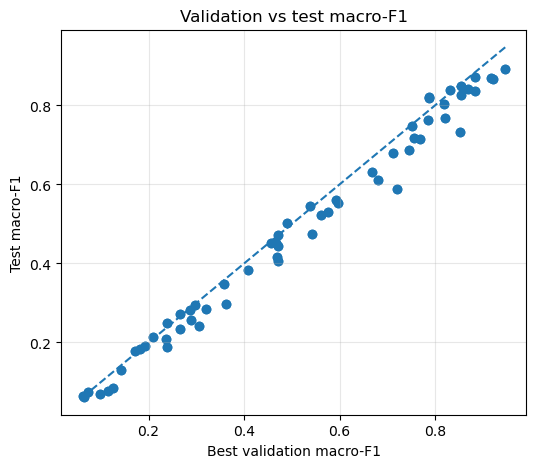

In [8]:
# -----------------------------
# 7. VALIDATION-TEST AGREEMENT
# -----------------------------
if {"best_val_macro_f1", "test_macro_f1"}.issubset(summary.columns):
    tmp = summary.copy()
    tmp["val_minus_test_macro_f1"] = tmp["best_val_macro_f1"] - tmp["test_macro_f1"]
    tmp = tmp.sort_values("val_minus_test_macro_f1", ascending=False)

    print("Largest validation-test macro-F1 gaps:")
    display(tmp[[c for c in [
        "run_name", "model_name", "pretrained", "freeze_backbone", "class_weight",
        "best_val_macro_f1", "test_macro_f1", "val_minus_test_macro_f1", "out_dir"
    ] if c in tmp.columns]].head(10))

    plt.figure(figsize=(6, 5))
    plt.scatter(summary["best_val_macro_f1"], summary["test_macro_f1"])

    lim_min = np.nanmin([
        summary["best_val_macro_f1"].min(),
        summary["test_macro_f1"].min()
    ])
    lim_max = np.nanmax([
        summary["best_val_macro_f1"].max(),
        summary["test_macro_f1"].max()
    ])
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")

    plt.xlabel("Best validation macro-F1")
    plt.ylabel("Test macro-F1")
    plt.title("Validation vs test macro-F1")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Need both best_val_macro_f1 and test_macro_f1 for this analysis.")


## 7. Training curves for top runs


efficientnet_b0__rel_path_seg__species_label__d613e883
history: outputs/efficientnet_b0__rel_path_seg__species_label__d613e883/history.csv


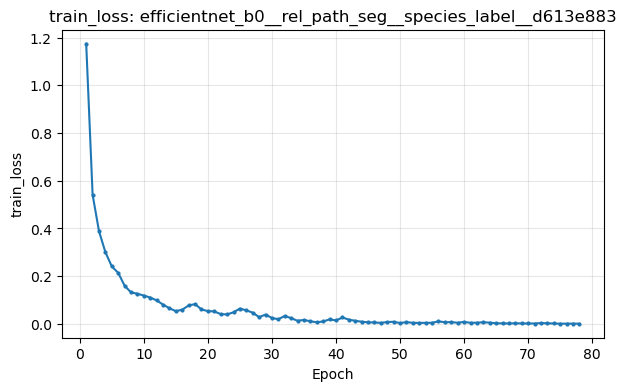

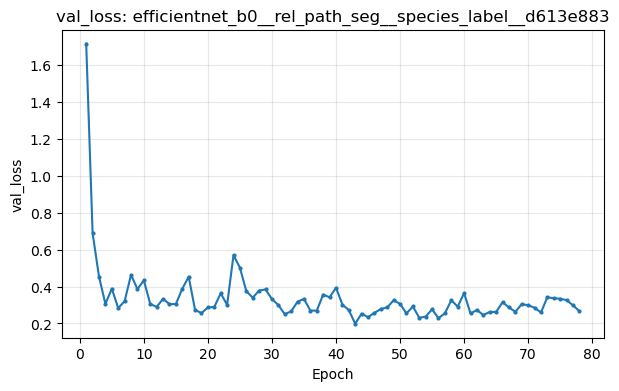

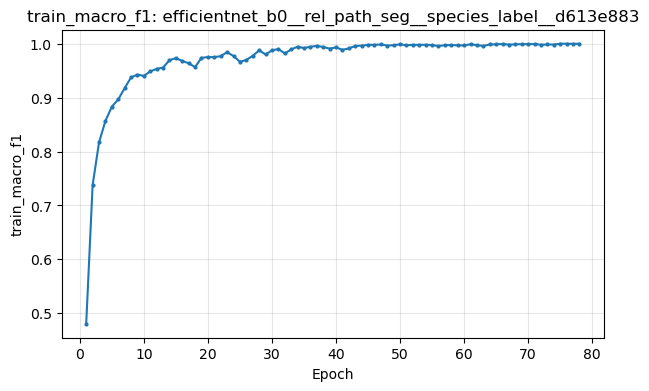

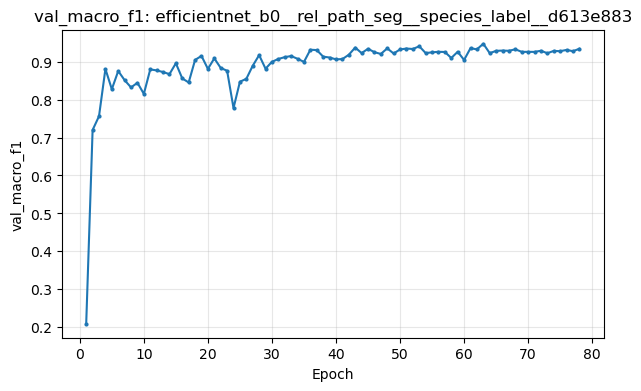

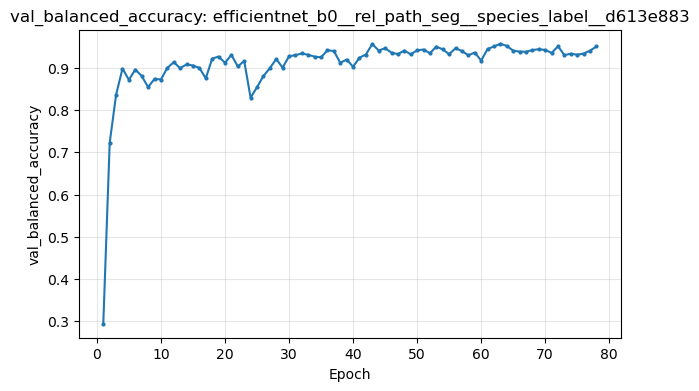

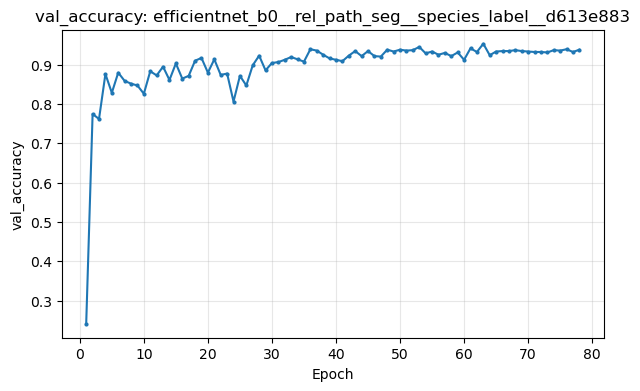


efficientnet_b0__rel_path_seg__species_label__80e7075a
history: outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a/history.csv


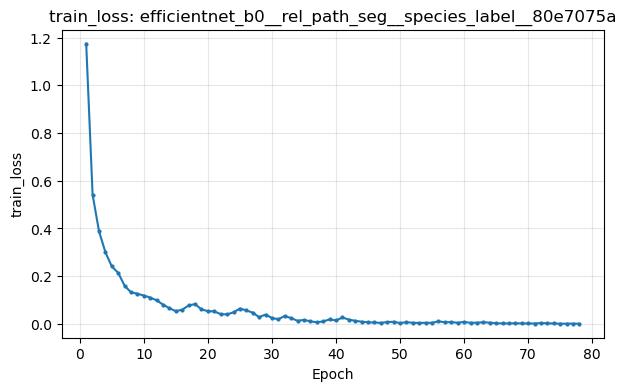

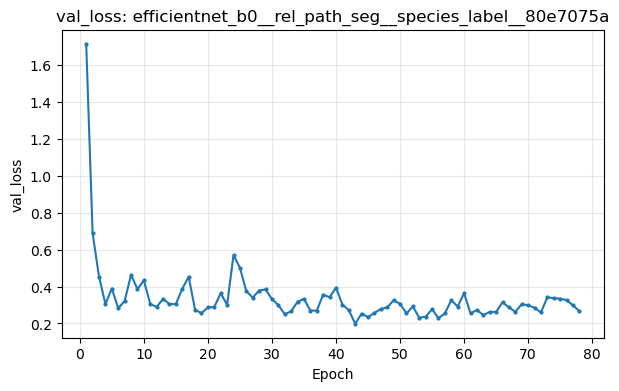

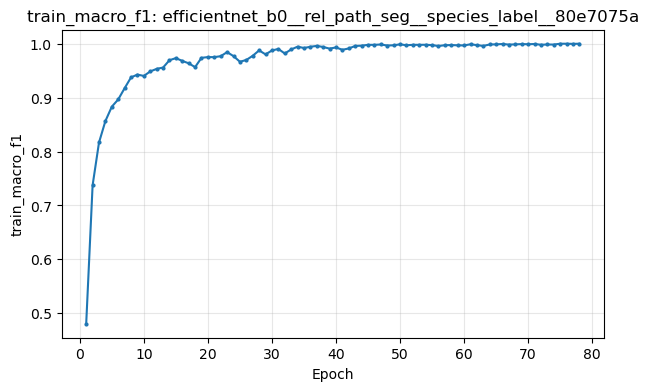

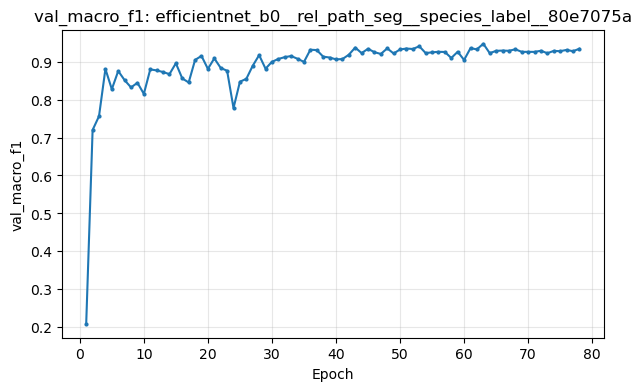

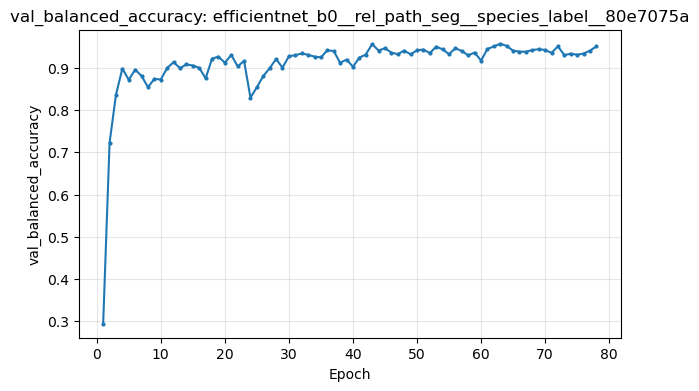

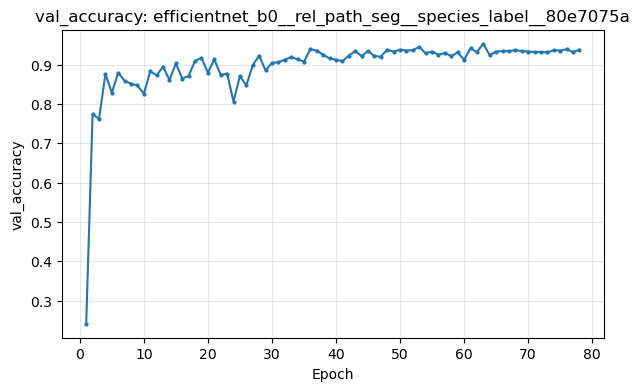


efficientnet_b0__rel_path_seg__species_label__5c0a3931
history: outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931/history.csv


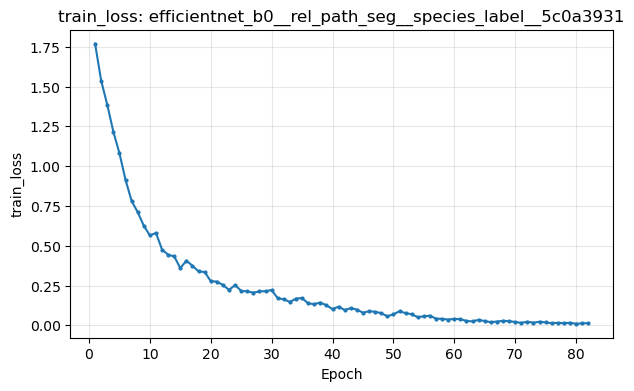

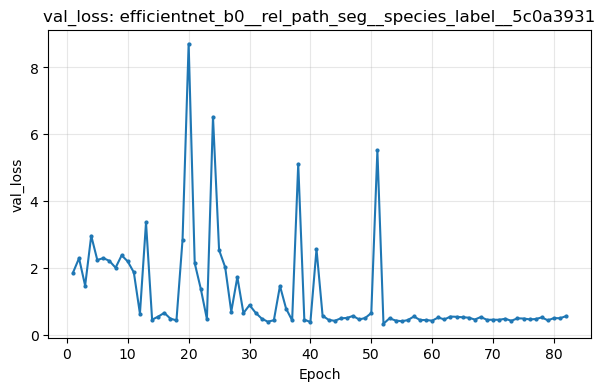

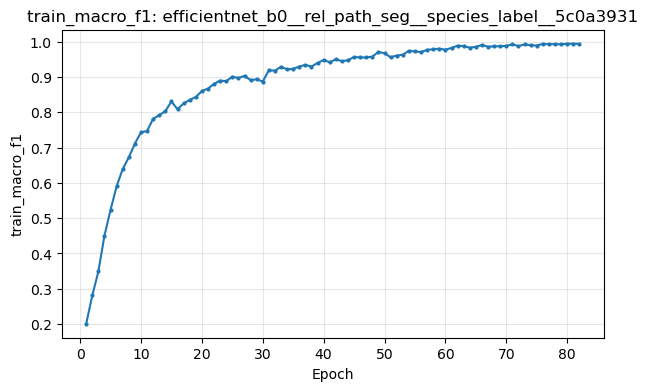

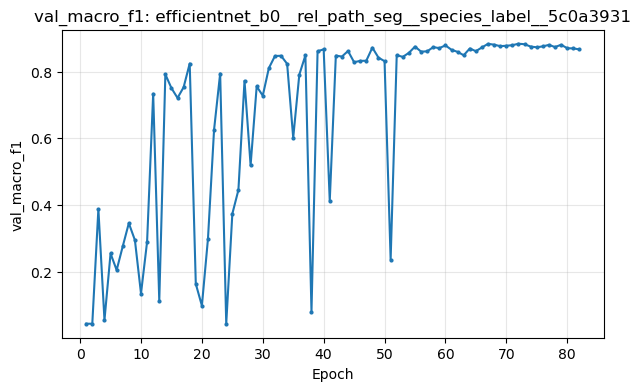

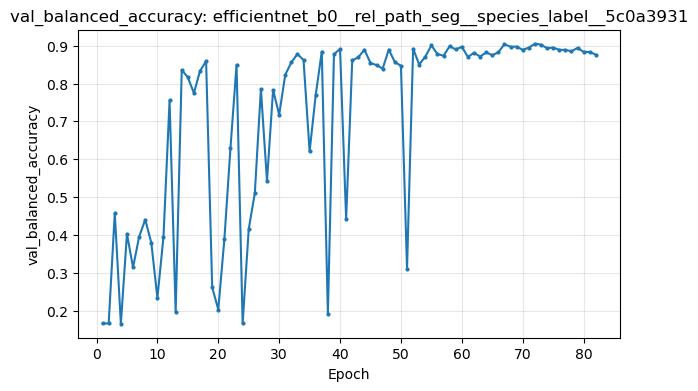

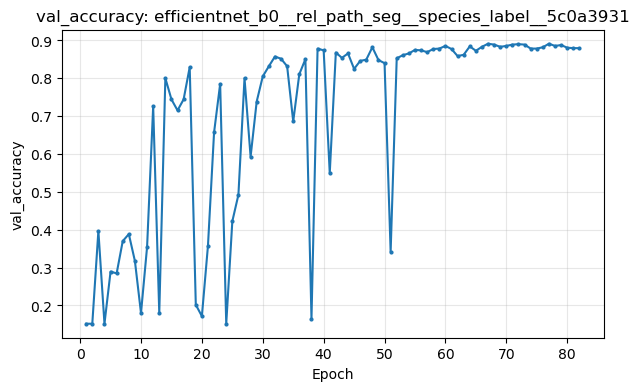


efficientnet_b0__rel_path_seg__species_label__7fd6ebbe
history: outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe/history.csv


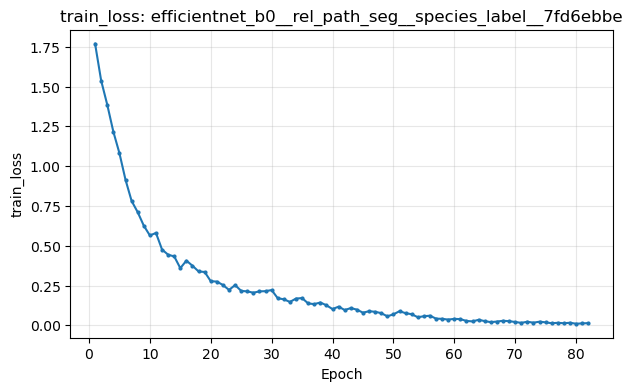

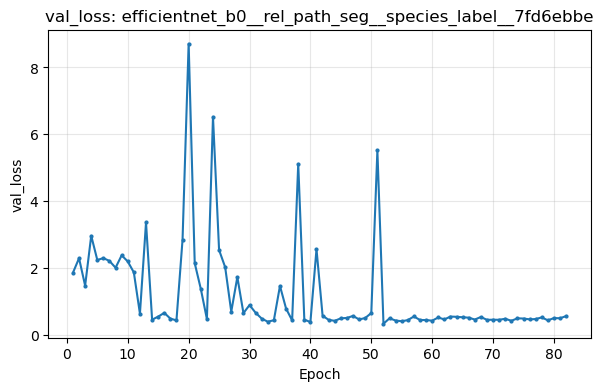

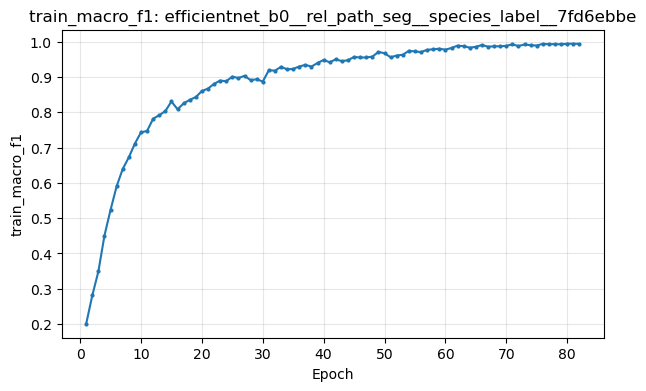

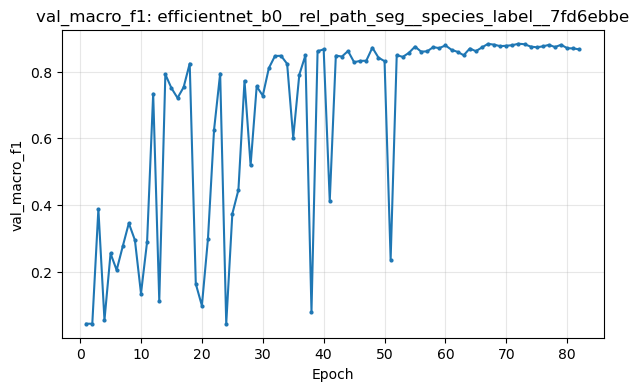

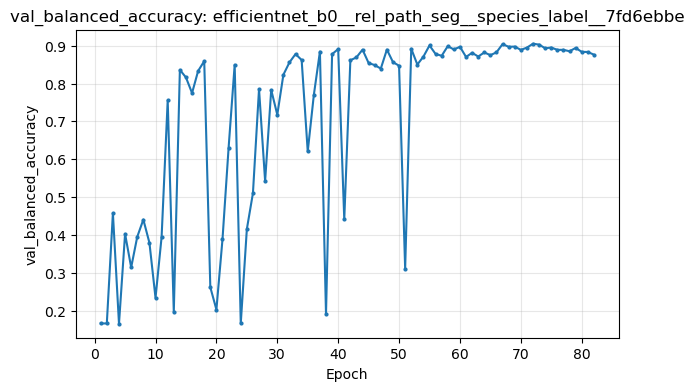

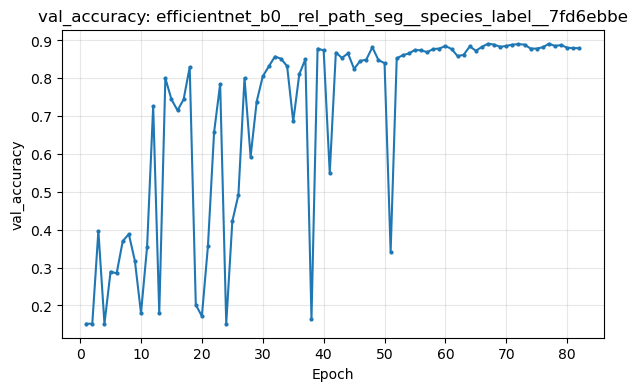


resnet50__rel_path_seg__species_label__3b4fed59
history: outputs/resnet50__rel_path_seg__species_label__3b4fed59/history.csv


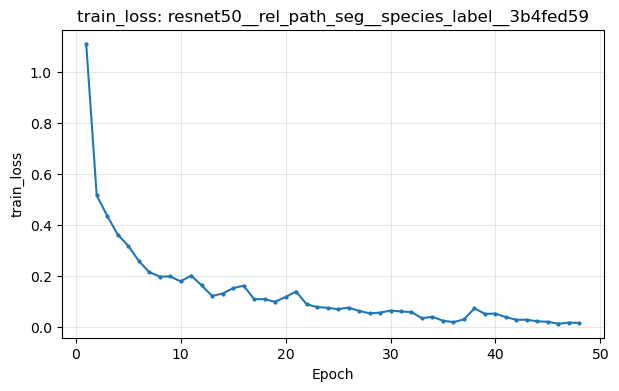

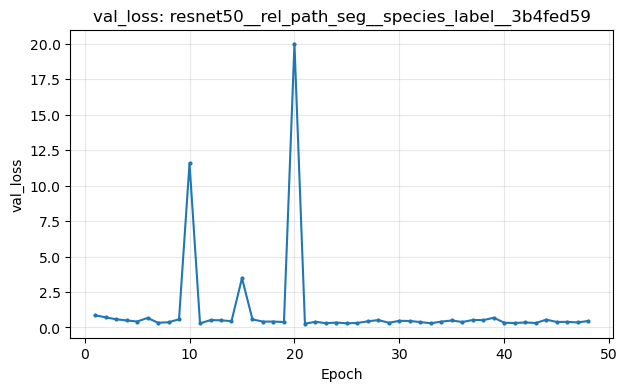

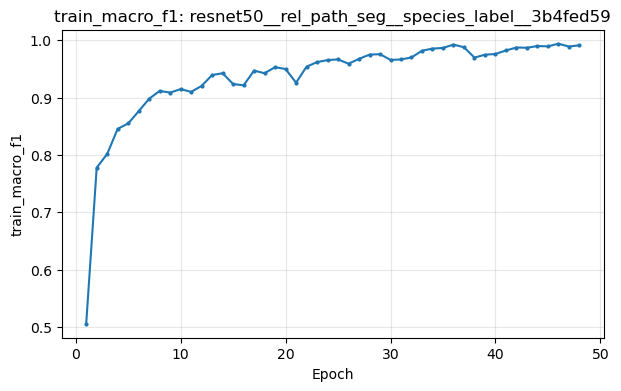

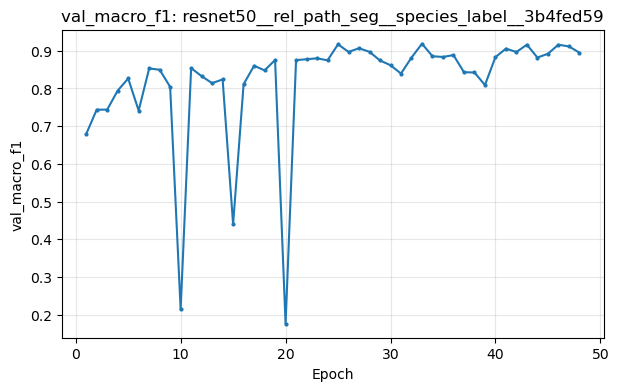

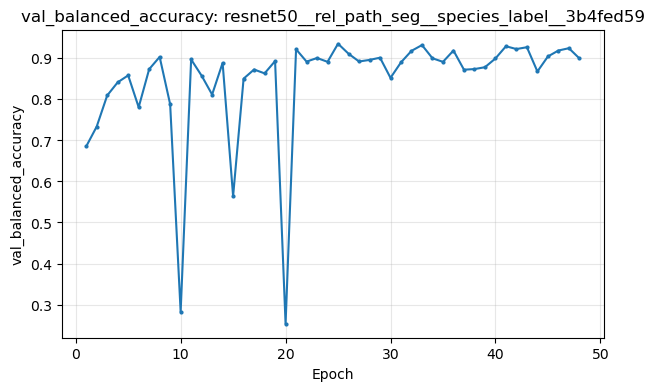

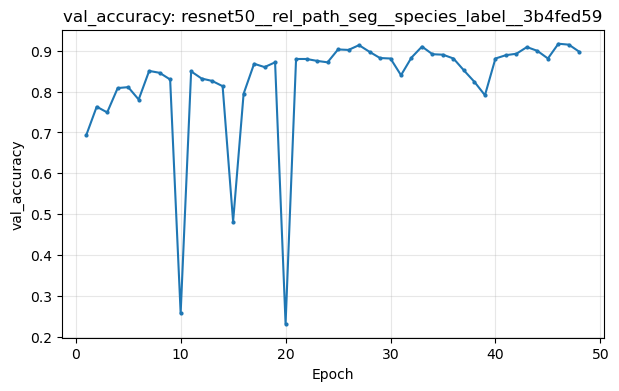

In [9]:
# -----------------------------
# 8. TRAINING CURVES
# -----------------------------
def plot_metric_curve(hist: pd.DataFrame, run_name: str, metric: str):
    if metric not in hist.columns:
        return

    if "epoch" not in hist.columns:
        hist = hist.copy()
        hist["epoch"] = np.arange(1, len(hist) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["epoch"], hist[metric], marker="o", markersize=2)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{metric}: {run_name}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_history(run_row):
    run_dir = Path(str(run_row["out_dir"]))
    hist_path = run_dir / "history.csv"

    if not hist_path.exists():
        print(f"No history.csv for {run_row['run_name']}")
        return

    hist = pd.read_csv(hist_path)
    print("\n" + "=" * 100)
    print(run_row["run_name"])
    print("history:", hist_path)

    for metric in ["train_loss", "val_loss", "train_macro_f1", "val_macro_f1", "val_balanced_accuracy", "val_accuracy"]:
        plot_metric_curve(hist, run_row["run_name"], metric)


for _, row in ranked.head(min(TOP_K_CONFUSION, len(ranked))).iterrows():
    plot_history(row)


## 8. Classification reports for top runs

This reads `classification_report.csv` and shows the species with the weakest F1-scores for the top runs.


In [10]:
# -----------------------------
# 9. CLASSIFICATION REPORTS
# -----------------------------
def load_classification_report(run_dir: Path) -> pd.DataFrame | None:
    path = run_dir / "classification_report.csv"
    if not path.exists():
        return None

    df = pd.read_csv(path)

    # Common case: first column contains class labels but is unnamed
    if df.columns[0].lower().startswith("unnamed"):
        df = df.rename(columns={df.columns[0]: "label"})

    # If there is no label column, treat the index-like first column as label
    if "label" not in df.columns:
        first_col = df.columns[0]
        if df[first_col].dtype == object:
            df = df.rename(columns={first_col: "label"})

    return df


def show_weakest_classes(run_row, n=10):
    run_dir = Path(str(run_row["out_dir"]))
    report = load_classification_report(run_dir)

    if report is None:
        print(f"No classification_report.csv for {run_row['run_name']}")
        return

    print("\n" + "=" * 100)
    print(run_row["run_name"])

    # Try to identify f1-score column
    f1_cols = [c for c in report.columns if str(c).lower().replace("_", "-") in ["f1-score", "f1"]]
    if not f1_cols:
        display(report.head(n))
        return

    f1_col = f1_cols[0]

    # Remove aggregate rows if present
    label_col = "label" if "label" in report.columns else report.columns[0]
    aggregate_labels = {"accuracy", "macro avg", "weighted avg", "micro avg"}
    per_class = report[~report[label_col].astype(str).str.lower().isin(aggregate_labels)].copy()

    per_class[f1_col] = pd.to_numeric(per_class[f1_col], errors="coerce")
    per_class = per_class.sort_values(f1_col, ascending=True)

    display(per_class.head(n))


for _, row in ranked.head(min(TOP_K_CONFUSION, len(ranked))).iterrows():
    show_weakest_classes(row, n=10)



efficientnet_b0__rel_path_seg__species_label__d613e883


,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.776596,0.618644,0.688679,118.0
1,Aporrectodea_caliginosa_tuberculata,0.883260,0.928241,0.905192,432.0
2,Aporrectodea_longa,0.928962,0.890052,0.909091,191.0
3,Aporrectodea_rosea,0.943396,0.909091,0.925926,55.0
0,Allolobophora_chlorotica,0.921659,0.966184,0.943396,207.0
5,Lumbricus_sp,0.969072,0.979167,0.974093,192.0



efficientnet_b0__rel_path_seg__species_label__80e7075a


,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.776596,0.618644,0.688679,118.0
1,Aporrectodea_caliginosa_tuberculata,0.883260,0.928241,0.905192,432.0
2,Aporrectodea_longa,0.928962,0.890052,0.909091,191.0
3,Aporrectodea_rosea,0.943396,0.909091,0.925926,55.0
0,Allolobophora_chlorotica,0.921659,0.966184,0.943396,207.0
5,Lumbricus_sp,0.969072,0.979167,0.974093,192.0



efficientnet_b0__rel_path_seg__species_label__5c0a3931


,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.672000,0.711864,0.691358,118.0
1,Aporrectodea_caliginosa_tuberculata,0.881797,0.863426,0.872515,432.0
2,Aporrectodea_longa,0.909574,0.895288,0.902375,191.0
3,Aporrectodea_rosea,0.909091,0.909091,0.909091,55.0
0,Allolobophora_chlorotica,0.909953,0.927536,0.918660,207.0
5,Lumbricus_sp,0.937824,0.942708,0.940260,192.0



efficientnet_b0__rel_path_seg__species_label__7fd6ebbe


,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.672000,0.711864,0.691358,118.0
1,Aporrectodea_caliginosa_tuberculata,0.881797,0.863426,0.872515,432.0
2,Aporrectodea_longa,0.909574,0.895288,0.902375,191.0
3,Aporrectodea_rosea,0.909091,0.909091,0.909091,55.0
0,Allolobophora_chlorotica,0.909953,0.927536,0.918660,207.0
5,Lumbricus_sp,0.937824,0.942708,0.940260,192.0



resnet50__rel_path_seg__species_label__3b4fed59


,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.766355,0.694915,0.728889,118.0
3,Aporrectodea_rosea,0.916667,0.800000,0.854369,55.0
1,Aporrectodea_caliginosa_tuberculata,0.898795,0.863426,0.880756,432.0
2,Aporrectodea_longa,0.898396,0.879581,0.888889,191.0
0,Allolobophora_chlorotica,0.850427,0.961353,0.902494,207.0
5,Lumbricus_sp,0.936275,0.994792,0.964646,192.0


## 9. Confusion matrices for top runs

This uses the saved `confusion_matrix.csv` files directly. No `test_predictions.csv` is required.


In [11]:
# -----------------------------
# 10. CONFUSION MATRIX HELPERS
# -----------------------------
def load_label_mapping(run_dir: Path) -> dict[int, str] | None:
    path = run_dir / "label_to_index.json"
    if not path.exists():
        return None

    d = read_json_if_exists(path)
    if not isinstance(d, dict):
        return None

    # label_to_index.json usually maps label -> index
    index_to_label = {}
    for label, idx in d.items():
        try:
            index_to_label[int(idx)] = str(label)
        except Exception:
            pass

    return index_to_label if index_to_label else None


def load_confusion_matrix(run_dir: Path) -> tuple[pd.DataFrame, Path] | tuple[None, None]:
    cm_path = run_dir / "confusion_matrix.csv"
    if not cm_path.exists():
        return None, None

    # First try: read with first column as index
    cm = pd.read_csv(cm_path, index_col=0)

    # If the first read gives a non-square matrix, try without index
    if cm.shape[0] != cm.shape[1]:
        cm = pd.read_csv(cm_path)

    # If labels are numeric and label_to_index exists, map them back to species names
    index_to_label = load_label_mapping(run_dir)
    if index_to_label is not None:
        def map_label(x):
            try:
                return index_to_label.get(int(x), str(x))
            except Exception:
                return str(x)

        if all(str(i).isdigit() for i in cm.index.astype(str)):
            cm.index = [map_label(i) for i in cm.index]
        if all(str(c).isdigit() for c in cm.columns.astype(str)):
            cm.columns = [map_label(c) for c in cm.columns]

    # If index is just 0..n and columns are also numeric, use label mapping if possible
    if index_to_label is not None and list(cm.index) == list(range(len(cm))):
        cm.index = [index_to_label.get(i, str(i)) for i in range(len(cm))]
    if index_to_label is not None:
        try:
            numeric_cols = [int(c) for c in cm.columns]
            if numeric_cols == list(range(len(cm.columns))):
                cm.columns = [index_to_label.get(i, str(i)) for i in numeric_cols]
        except Exception:
            pass

    # Ensure values are numeric
    cm = cm.apply(pd.to_numeric, errors="coerce").fillna(0)

    return cm, cm_path


def normalise_cm_by_row(cm: pd.DataFrame) -> pd.DataFrame:
    row_sums = cm.sum(axis=1).replace(0, np.nan)
    return cm.div(row_sums, axis=0).fillna(0)


def plot_confusion_matrix_from_csv(run_row, normalise=True, annotate=True):
    run_dir = Path(str(run_row["out_dir"]))
    cm, cm_path = load_confusion_matrix(run_dir)

    if cm is None:
        print(f"No confusion_matrix.csv for {run_row['run_name']}")
        return

    cm_plot = normalise_cm_by_row(cm) if normalise else cm

    labels = list(cm_plot.index.astype(str))
    n = len(labels)

    fig_w = max(8, 0.55 * n)
    fig_h = max(7, 0.50 * n)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(cm_plot.values, aspect="auto")
    fig.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    metric_text = ""
    if "test_macro_f1" in run_row and pd.notna(run_row["test_macro_f1"]):
        metric_text = f" | test macro-F1={float(run_row['test_macro_f1']):.3f}"

    title = f"{run_row['run_name']}{metric_text}"
    if normalise:
        title += " | row-normalised"
    ax.set_title(title)

    if annotate and n <= 20:
        values = cm_plot.values
        for i in range(n):
            for j in range(n):
                val = values[i, j]
                text = f"{val:.2f}" if normalise else f"{int(val)}"
                ax.text(j, i, text, ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    print("Confusion matrix:", cm_path)
    print("Rows = true labels; columns = predicted labels")

    return cm


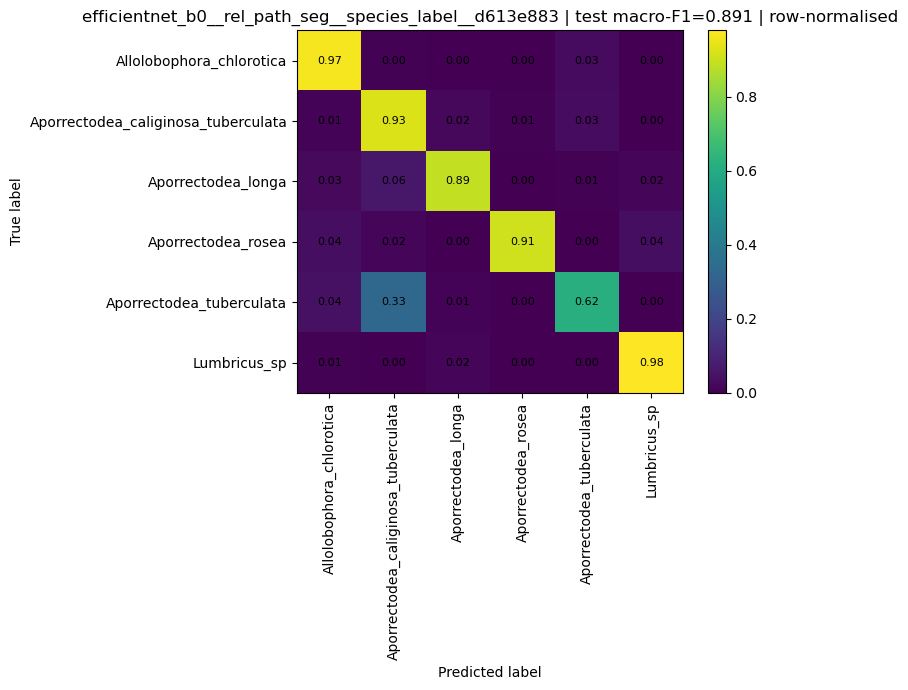

Confusion matrix: outputs/efficientnet_b0__rel_path_seg__species_label__d613e883/confusion_matrix.csv
Rows = true labels; columns = predicted labels


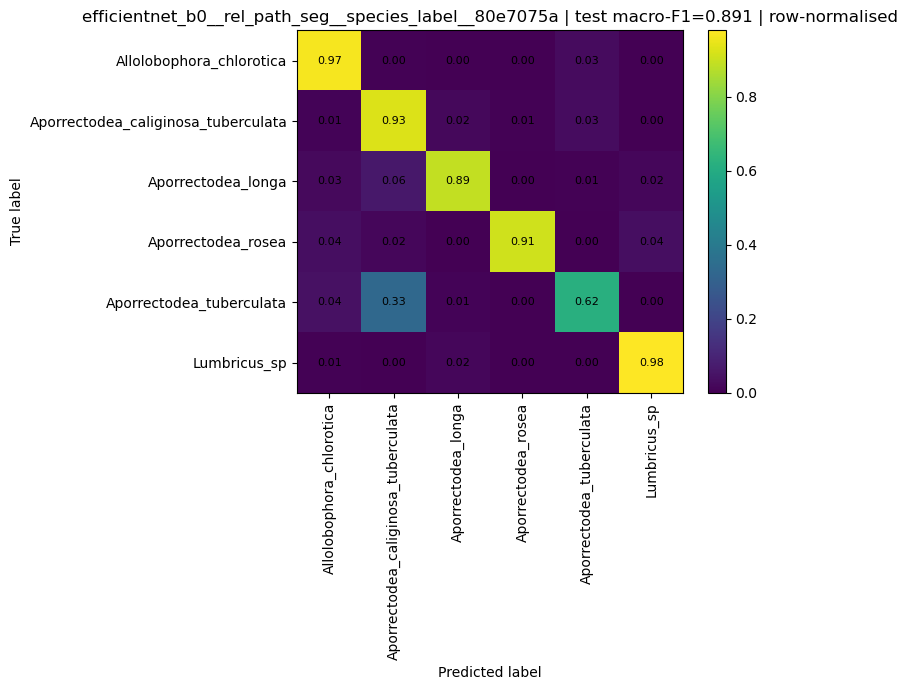

Confusion matrix: outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a/confusion_matrix.csv
Rows = true labels; columns = predicted labels


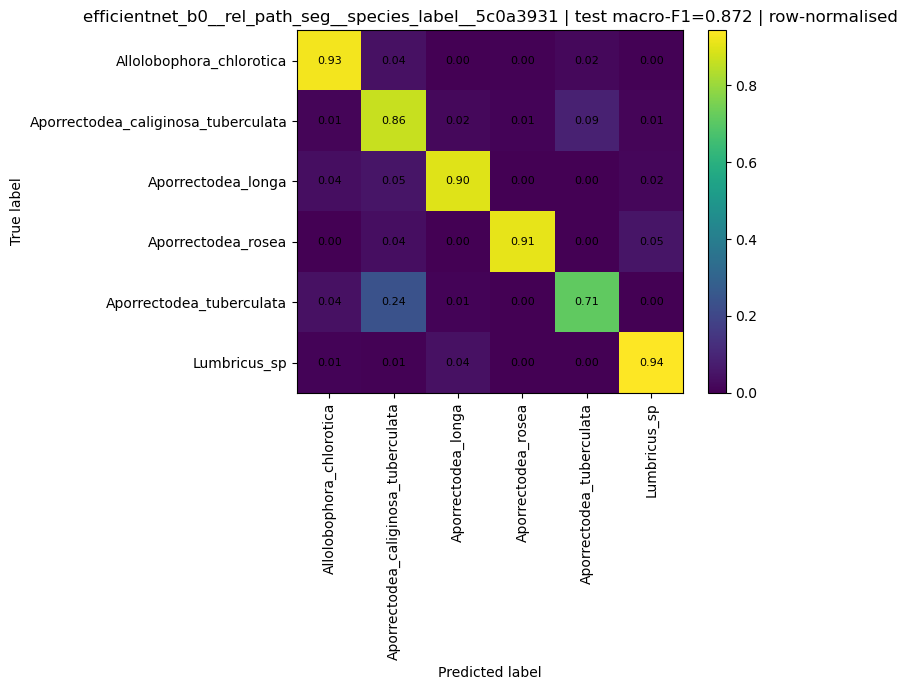

Confusion matrix: outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931/confusion_matrix.csv
Rows = true labels; columns = predicted labels


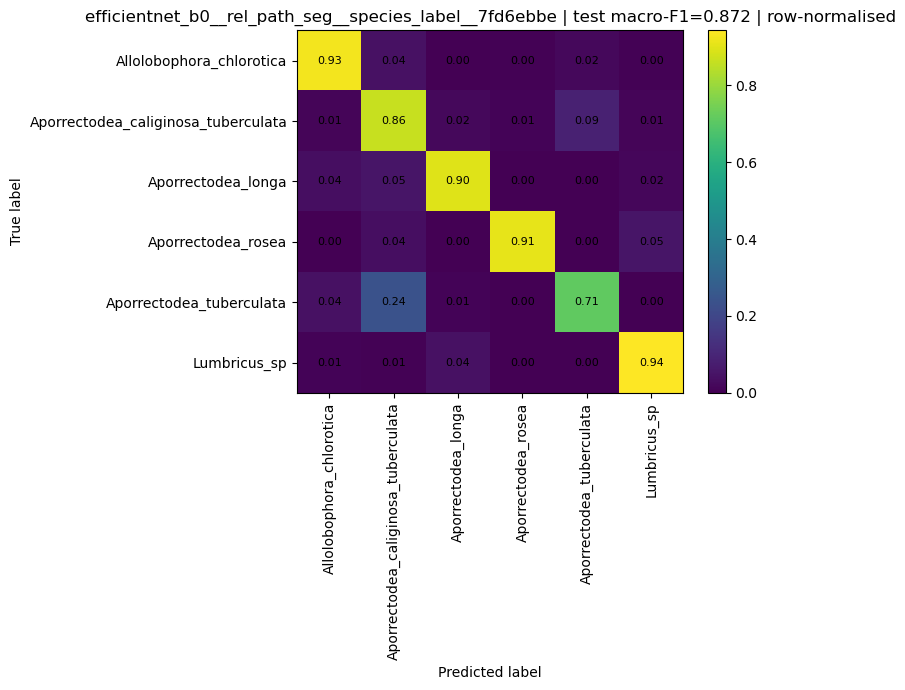

Confusion matrix: outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe/confusion_matrix.csv
Rows = true labels; columns = predicted labels


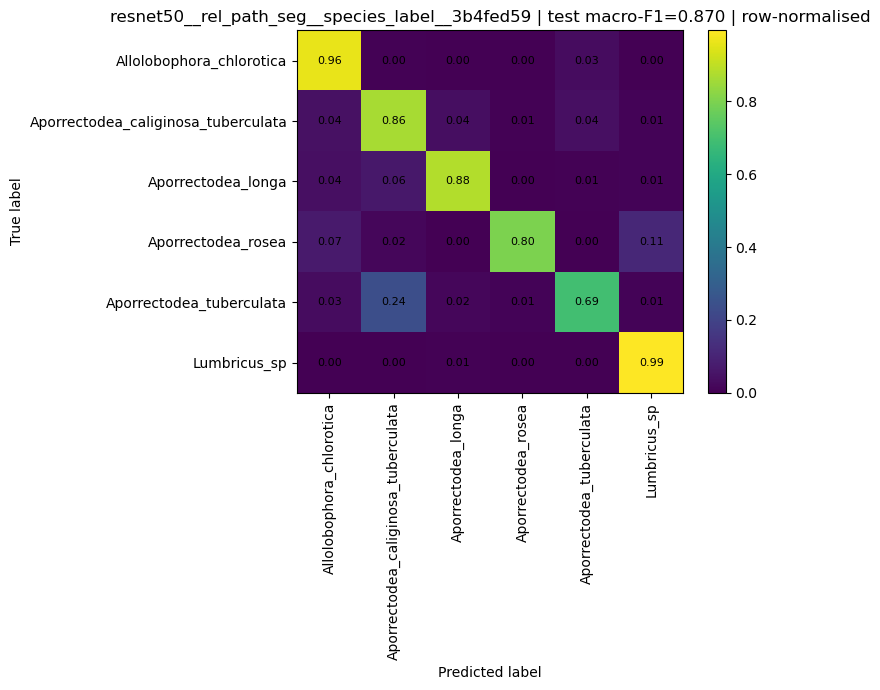

Confusion matrix: outputs/resnet50__rel_path_seg__species_label__3b4fed59/confusion_matrix.csv
Rows = true labels; columns = predicted labels


In [12]:
# -----------------------------
# 11. PLOT TOP CONFUSION MATRICES
# -----------------------------
top_with_cm = ranked[ranked["has_confusion_matrix"] == True].head(TOP_K_CONFUSION)

if len(top_with_cm) == 0:
    print("No confusion_matrix.csv files found in the ranked runs.")
else:
    for _, row in top_with_cm.iterrows():
        plot_confusion_matrix_from_csv(row, normalise=True, annotate=True)


In [15]:
# -----------------------------
# PRINT ALL DESIGN CHOICES FOR TOP MODEL
# -----------------------------
from pathlib import Path
import json
import pandas as pd
import numpy as np

# Choose ranking metric
rank_metric = "test_macro_f1"

# Select top model
top_row = ranked.sort_values(rank_metric, ascending=False).iloc[0]
top_run_dir = Path(top_row["out_dir"])

print("=" * 100)
print("TOP MODEL")
print("=" * 100)
print(f"Run name: {top_row['run_name']}")
print(f"Run directory: {top_run_dir}")
print(f"Ranking metric: {rank_metric}")
print(f"{rank_metric}: {top_row[rank_metric]:.4f}")

# -----------------------------
# Load files
# -----------------------------
def load_json(path):
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return None

cfg = load_json(top_run_dir / "config.json")
test_metrics = load_json(top_run_dir / "test_metrics.json")
split_summary = load_json(top_run_dir / "split_summary.json")

history_path = top_run_dir / "history.csv"
history = pd.read_csv(history_path) if history_path.exists() else None

report_path = top_run_dir / "classification_report.csv"
report = pd.read_csv(report_path) if report_path.exists() else None

# -----------------------------
# Print config/design choices
# -----------------------------
print("\n" + "=" * 100)
print("MODEL DESIGN")
print("=" * 100)

model_cfg = cfg.get("model", {}) if cfg else {}
for k, v in model_cfg.items():
    print(f"{k}: {v}")

print("\n" + "=" * 100)
print("DATA SETTINGS")
print("=" * 100)

data_cfg = cfg.get("data", {}) if cfg else {}
for k, v in data_cfg.items():
    print(f"{k}: {v}")

print("\n" + "=" * 100)
print("TRAINING SETTINGS")
print("=" * 100)

training_cfg = cfg.get("training", {}) if cfg else {}
for k, v in training_cfg.items():
    print(f"{k}: {v}")

print("\n" + "=" * 100)
print("CACHE SETTINGS")
print("=" * 100)

cache_cfg = cfg.get("cache", {}) if cfg else {}
for k, v in cache_cfg.items():
    print(f"{k}: {v}")

print("\n" + "=" * 100)
print("EARLY STOPPING SETTINGS")
print("=" * 100)

early_cfg = cfg.get("early_stopping", {}) if cfg else {}
if early_cfg:
    for k, v in early_cfg.items():
        print(f"{k}: {v}")
else:
    print("No early_stopping section found in config.json")

# -----------------------------
# Print test metrics
# -----------------------------
print("\n" + "=" * 100)
print("TEST METRICS")
print("=" * 100)

if test_metrics:
    for k, v in test_metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")
else:
    print("No test_metrics.json found")

# -----------------------------
# Print training history summary
# -----------------------------
print("\n" + "=" * 100)
print("TRAINING HISTORY SUMMARY")
print("=" * 100)

if history is not None:
    print(f"Epochs run: {len(history)}")

    if "val_macro_f1" in history.columns:
        best_idx = history["val_macro_f1"].idxmax()
        best_epoch = int(history.loc[best_idx, "epoch"]) if "epoch" in history.columns else best_idx + 1

        print(f"Best validation macro-F1 epoch: {best_epoch}")
        print(f"Best validation macro-F1: {history.loc[best_idx, 'val_macro_f1']:.4f}")

        if "val_balanced_accuracy" in history.columns:
            print(f"Validation balanced accuracy at best epoch: {history.loc[best_idx, 'val_balanced_accuracy']:.4f}")

        if "val_accuracy" in history.columns:
            print(f"Validation accuracy at best epoch: {history.loc[best_idx, 'val_accuracy']:.4f}")

        if "val_loss" in history.columns:
            print(f"Validation loss at best epoch: {history.loc[best_idx, 'val_loss']:.4f}")

    print("\nFinal epoch metrics:")
    final = history.iloc[-1]
    for col in history.columns:
        if col == "epoch":
            continue
        val = final[col]
        if isinstance(val, (int, float, np.floating)):
            print(f"{col}: {val:.4f}")
        else:
            print(f"{col}: {val}")
else:
    print("No history.csv found")

# -----------------------------
# Print split summary
# -----------------------------
print("\n" + "=" * 100)
print("DATA SPLIT SUMMARY")
print("=" * 100)

if split_summary:
    print(json.dumps(split_summary, indent=2))
else:
    print("No split_summary.json found")

# -----------------------------
# Print weakest species/classes
# -----------------------------
print("\n" + "=" * 100)
print("WEAKEST CLASSES BY F1-SCORE")
print("=" * 100)

if report is not None:
    # Fix common unnamed label column
    if report.columns[0].lower().startswith("unnamed"):
        report = report.rename(columns={report.columns[0]: "label"})

    if "label" not in report.columns:
        report = report.rename(columns={report.columns[0]: "label"})

    f1_col = None
    for c in report.columns:
        if c.lower().replace("_", "-") in ["f1-score", "f1"]:
            f1_col = c
            break

    if f1_col is not None:
        aggregate_rows = {"accuracy", "macro avg", "weighted avg", "micro avg"}
        per_class = report[
            ~report["label"].astype(str).str.lower().isin(aggregate_rows)
        ].copy()

        per_class[f1_col] = pd.to_numeric(per_class[f1_col], errors="coerce")
        per_class = per_class.sort_values(f1_col, ascending=True)

        display(per_class.head(10))
    else:
        print("Could not find F1-score column.")
        display(report.head())
else:
    print("No classification_report.csv found")

TOP MODEL
Run name: efficientnet_b0__rel_path_seg__species_label__d613e883
Run directory: outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
Ranking metric: test_macro_f1
test_macro_f1: 0.8911

MODEL DESIGN
name: efficientnet_b0
pretrained: True
freeze_backbone: False

DATA SETTINGS
root_dir: /mnt/extssd/Earthworms/petridish-worm-images
metadata_csv: /mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/global_metadata.csv
image_col: rel_path_seg
mask_col: rel_path_segmask
target_col: species_label
group_col: barcode
strip_final_number_from_group: False
min_individuals_per_class: 50
crop_to_foreground: False
crop_pad: 0.15
image_size: 224

TRAINING SETTINGS
epochs: 100
batch_size: 128
lr: 0.001
weight_decay: 0.0001
use_amp: True
class_weight: True
num_workers: 8

CACHE SETTINGS
enabled: True
dir: cache/images
root_dir_cache: /home/devd/worm-species
format: png
rebuild: False
num_workers: 8

EARLY STOPPING SETTINGS
enabled: True
monitor: macro_f1
mode: max
patience: 15
m

,label,precision,recall,f1-score,support
4,Aporrectodea_tuberculata,0.776596,0.618644,0.688679,118.0
1,Aporrectodea_caliginosa_tuberculata,0.883260,0.928241,0.905192,432.0
2,Aporrectodea_longa,0.928962,0.890052,0.909091,191.0
3,Aporrectodea_rosea,0.943396,0.909091,0.925926,55.0
0,Allolobophora_chlorotica,0.921659,0.966184,0.943396,207.0
5,Lumbricus_sp,0.969072,0.979167,0.974093,192.0


## 10. Mean performance by condition

This is useful for seeing whether `pretrained`, `freeze_backbone`, or `class_weight` consistently helps across architectures. Interpret cautiously if the number of runs per condition is small.


In [13]:
# -----------------------------
# 12. CONDITION-LEVEL MEANS
# -----------------------------
condition_cols = ["model_name", "pretrained", "freeze_backbone", "class_weight", "image_size"]
condition_cols = [c for c in condition_cols if c in summary.columns]

metric_cols = [
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_accuracy",
    "test_loss",
    "best_val_macro_f1",
    "n_epochs_ran",
]
metric_cols = [c for c in metric_cols if c in summary.columns]

if condition_cols and metric_cols:
    condition_summary = (
        summary
        .groupby(condition_cols, dropna=False)[metric_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    display(condition_summary)
else:
    print("Not enough condition or metric columns for condition-level summaries.")


model_name pretrained freeze_backbone class_weight image_size test_macro_f1                 test_balanced_accuracy                 test_accuracy                  \
                                                                                mean       std count                   mean       std count          mean       std count   
0   efficientnet_b0      False           False        False        224      0.785870  0.097441     3               0.799345  0.088047     3      0.827370  0.056151     3   
1   efficientnet_b0      False           False         True        224      0.785870  0.097441     3               0.799345  0.088047     3      0.827370  0.056151     3   
2   efficientnet_b0      False            True        False        224      0.133555  0.049564     3               0.191706  0.041070     3      0.202258  0.052480     3   
3   efficientnet_b0      False            True         True        224      0.133555  0.049564     3               0.191706  0.041070     3      0.202258  0.052480     3   
4   efficientnet_b0       True           False        False        224      0.816154  0.079885     3               0.812991  0.079475     3      0.878959  0.022997     3   
5   efficientnet_b0       True           False         True        224      0.816154  0.079885     3               0.812991  0.079475     3      0.878959  0.022997     3   
6   efficientnet_b0       True            True        False        224      0.471186  0.074759     3               0.509969  0.063456     3      0.525101  0.056690     3   
7   efficientnet_b0       True            True         True        224      0.471186  0.074759     3               0.509969  0.063456     3      0.525101  0.056690     3   
8          resnet18      False           False        False        224      0.801673  0.046462     3               0.818877  0.037803     3      0.832021  0.029494     3   
9          resnet18      False           False         True        224      0.801673  0.046462     3               0.818877  0.037803     3      0.832021  0.029494     3   
10         resnet18      False            True        False        224      0.244581  0.036765     3               0.270459  0.007284     3      0.282148  0.037873     3   
11         resnet18      False            True         True        224      0.244581  0.036765     3               0.270459  0.007284     3      0.282148  0.037873     3   
12         resnet18       True           False        False        224      0.822996  0.052634     3               0.829565  0.028996     3      0.863569  0.027365     3   
13         resnet18       True           False         True        224      0.822996  0.052634     3               0.829565  0.028996     3      0.863569  0.027365     3   
14         resnet18       True            True        False        224      0.444981  0.028312     3               0.468636  0.025297     3      0.501179  0.039977     3   
15         resnet18       True            True         True        224      0.444981  0.028312     3               0.468636  0.025297     3      0.501179  0.039977     3   
16         resnet50      False           False        False        224      0.795083  0.070348     3               0.820555  0.074552     3      0.835787  0.015027     3   
17         resnet50      False           False         True        224      0.795083  0.070348     3               0.820555  0.074552     3      0.835787  0.015027     3   
18         resnet50      False            True        False        224      0.259845  0.062780     3               0.306956  0.008851     3      0.317660  0.063016     3   
19         resnet50      False            True         True        224      0.259845  0.062780     3               0.306956  0.008851     3      0.317660  0.063016     3   
20         resnet50       True           False        False        224      0.800243  0.097773     3               0.805829  0.082582     3      0.849199  0.054324     3   
21         resnet50       True

## 11. Save analysis outputs

In [14]:
# -----------------------------
# 13. EXPORT TABLES
# -----------------------------
analysis_dir = OUTPUT_ROOT / "_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

summary_path = analysis_dir / "all_runs_summary.csv"
ranked_path = analysis_dir / "ranked_runs.csv"
filtered_ranked_path = analysis_dir / "ranked_runs_filtered.csv"

summary.to_csv(summary_path, index=False)
ranked.to_csv(ranked_path, index=False)
filtered_ranked.to_csv(filtered_ranked_path, index=False)

print("Saved:", summary_path)
print("Saved:", ranked_path)
print("Saved:", filtered_ranked_path)

for title, tbl in best_tables.items():
    safe = re.sub(r"[^a-zA-Z0-9_]+", "_", title.lower()).strip("_")
    path = analysis_dir / f"{safe}.csv"
    tbl.to_csv(path, index=False)
    print("Saved:", path)

display(ranked[cols_main].head(TOP_K))


Saved: outputs/_analysis/all_runs_summary.csv
Saved: outputs/_analysis/ranked_runs.csv
Saved: outputs/_analysis/ranked_runs_filtered.csv
Saved: outputs/_analysis/best_per_model.csv
Saved: outputs/_analysis/best_per_pretrained_setting.csv
Saved: outputs/_analysis/best_per_freeze_backbone_setting.csv
Saved: outputs/_analysis/best_per_class_weight_setting.csv
Saved: outputs/_analysis/best_per_model_pretrained.csv
Saved: outputs/_analysis/best_per_model_freeze_backbone.csv
Saved: outputs/_analysis/best_per_model_class_weight.csv
Saved: outputs/_analysis/best_per_full_case.csv


,rank,run_name,model_name,pretrained,freeze_backbone,class_weight,image_size,best_val_macro_f1,test_macro_f1,test_balanced_accuracy,test_accuracy,test_loss,n_epochs_ran,best_epoch_by_val_macro_f1,frozen_random_backbone,has_confusion_matrix,out_dir
0,1,efficientnet_b0__rel_path_seg__species_label__d613e883,efficientnet_b0,True,False,True,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__d613e883
1,2,efficientnet_b0__rel_path_seg__species_label__80e7075a,efficientnet_b0,True,False,False,224,0.947435,0.891063,0.881896,0.905439,0.637097,78.0,63.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__80e7075a
2,3,efficientnet_b0__rel_path_seg__species_label__5c0a3931,efficientnet_b0,False,False,False,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__5c0a3931
3,4,efficientnet_b0__rel_path_seg__species_label__7fd6ebbe,efficientnet_b0,False,False,True,224,0.883488,0.872376,0.874986,0.879498,0.662080,82.0,72.0,False,True,outputs/efficientnet_b0__rel_path_seg__species_label__7fd6ebbe
4,5,resnet50__rel_path_seg__species_label__3b4fed59,resnet50,True,False,True,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,True,outputs/resnet50__rel_path_seg__species_label__3b4fed59
5,6,resnet50__rel_path_seg__species_label__444ed097,resnet50,True,False,False,224,0.918381,0.870007,0.865678,0.884519,0.537155,48.0,33.0,False,True,outputs/resnet50__rel_path_seg__species_label__444ed097
6,7,resnet18__rel_path_seg__species_label__fc235d3a,resnet18,True,False,True,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,True,outputs/resnet18__rel_path_seg__species_label__fc235d3a
7,8,resnet18__rel_path_seg__species_label__a6e23b1f,resnet18,True,False,False,224,0.921137,0.866286,0.851867,0.882845,0.596428,48.0,33.0,False,True,outputs/resnet18__rel_path_seg__species_label__a6e23b1f
8,9,resnet50__rel_path_seg__species_label__03f76fef,resnet50,False,False,True,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,True,outputs/resnet50__rel_path_seg__species_label__03f76fef
9,10,resnet50__rel_path_seg__species_label__cefdfc0c,resnet50,False,False,False,224,0.855063,0.848263,0.878925,0.848536,0.454577,53.0,38.0,False,True,outputs/resnet50__rel_path_seg__species_label__cefdfc0c


## 12. Suggested interpretation template

After running the notebook, use the following structure in your notes:

1. Identify the best overall run by test macro-F1.
2. Check whether the same run also performs well in balanced accuracy.
3. Compare pretrained versus non-pretrained runs.
4. Compare frozen versus unfrozen backbones, excluding `pretrained=False + freeze_backbone=True`.
5. Inspect the weakest species in `classification_report.csv`.
6. Inspect whether the confusion matrix shows biologically meaningful confusion, for example between morphologically similar species.

For a paper or internal report, avoid relying on a single split. The next stronger analysis would repeat the best configurations across multiple random seeds and report mean ± standard deviation.
